#Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the dataset

In [2]:
df=pd.read_csv("WELFake_Dataset.csv")

#Data Analysis

In [3]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [7]:
df.shape

(72134, 3)

In [8]:
df["label"].value_counts()

,count
label,
1,37106
0,35028


### Duplicate value Analysis

In [9]:
df.duplicated().sum()

np.int64(8456)

In [10]:
df.drop_duplicates(inplace=True)

### Missing Values

In [11]:
df.isnull().sum()

,0
title,518
text,39
label,0


In [12]:
df[df['title'].isnull()].head()

,title,text,label
1,NaN,Did they post their votes for Hillary already?,1
43,NaN,True. Hillary needs a distraction and what bet...,1
162,NaN,All eyes on Electoral delegates. The People kn...,1
185,NaN,Cool,1
269,NaN,A leading US senator: US Supporting War in Syr...,1


In [13]:
df[df['text'].isnull()].head()

,title,text,label
2457,Après le succès de « Mariés au premier regard ...,NaN,1
3534,Elections US : les premières estimations donne...,NaN,1
3709,110% des Américains assurent qu’ils continuero...,NaN,1
5612,Des millions d’Américains recherchent massivem...,NaN,1
6270,Vladimir Poutine est élu 45e Président des Eta...,NaN,1


In [14]:
df = df.dropna(subset=['text'])

In [15]:
df["title"]=df["title"].fillna("")

In [16]:
df.isnull().sum()

,0
title,0
text,0
label,0


###Observation:
--> I dropped the rows which didnt contain any texts.

--> I filled the `title`columns which contain any NAN values with an empty string because the text is far more important than title.


# EDA

##Basic stats

In [17]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
0,54.669307
1,45.330693


In [18]:
df.describe()

,label
count,63639.000000
mean,0.453307
std,0.497819
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [19]:
df.describe(include='object')

,title,text
count,63639,63639
unique,62309,62718
top,,
freq,518,525


## Article Info

In [20]:
df['char_count'] = df['text'].apply(len)

df['word_count'] = df['text'].apply(lambda x: len(x.split()))

df['sentence_count'] = df['text'].apply(lambda x: len(x.split('.')))

In [21]:
df[['char_count',
    'word_count',
    'sentence_count']].describe()

,char_count,word_count,sentence_count
count,63639.000000,63639.000000,63639.000000
mean,3278.760964,542.645925,30.452788
std,3636.478460,610.451515,36.207776
min,1.000000,0.000000,1.000000
25%,1431.000000,235.000000,12.000000
50%,2457.000000,403.000000,22.000000
75%,4097.000000,674.000000,37.000000
max,142961.000000,24234.000000,1336.000000


In [22]:
df.groupby('label')[['word_count',
                     'char_count',
                     'sentence_count']].mean()

,word_count,char_count,sentence_count
label,,,
0,578.252278,3498.913685,34.259262
1,499.704278,3013.254402,25.862139


###Removing those rows where word_count=0

In [23]:
df[df['word_count'] == 0]

,title,text,label,char_count,word_count,sentence_count
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1,1,0,1
106,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trum...,,1,1,0,1
325,Ohio State University Student Says Terrorist A...,,1,1,0,1
364,JULIAN ASSANGE REVEALS John Podesta’s Hilariou...,,1,1,0,1
512,OBAMA’S LIST OF 21 MEDAL OF FREEDOM Recipients...,,1,1,0,1
...,...,...,...,...,...,...
71660,"“White Boys”–The NYT Celebrates Neera Tanden,’...",,1,1,0,1
71721,MEDIA BUSTED! 2003 VIDEO Of TRUMP Proving His ...,,1,1,0,1
71771,WOW! JILL STEIN’S ‘FIRESIDE CHAT’ Exposes Her ...,,1,1,0,1
72026,BOOM! Woman Tries To Steal TRUMP Signs BUT Thi...,,1,1,0,1


In [24]:
df.loc[df['word_count'] == 0, 'text'].head()

,text
7,
106,
325,
364,
512,


In [25]:
df = df[df['word_count'] > 0]

### Understanding the lengthy articles

In [26]:
df.nlargest(5, 'word_count')[['title', 'word_count']]

,title,word_count
327,Re: The Hard Working American vs. The Governme...,24234
34523,Re: Why Are So Many People Choosing To Leave T...,20891
6445,Заседание Международного дискуссионного клуба ...,20876
17557,Re: How Many People Will Have To Migrate Out O...,20084
71687,Re: 55 Reasons Why California Is The Worst Sta...,17427


In [27]:
longest_article = df.loc[df['word_count'].idxmax()]

print(longest_article['title'])
print("-" * 100)
print(longest_article['text'][:5000])

Re: The Hard Working American vs. The Government Parasite
----------------------------------------------------------------------------------------------------
The Hard Working American vs. The Government Parasite By Michael Snyder, on April 10th, 2012 
Which lifestyle choice produces better results – being a hard working American or being a government parasite? Actually, when you look at the cold, hard numbers they may just surprise you. In America today, we deeply penalize hard work and we greatly reward government dependence. If you live in a very liberal area of the country and you know how to game the system, it is entirely possible to live a comfortable existence without ever working too much at all. In fact, there are some Americans that have been living off of “government benefits” for decades. Many of these people actually plan their lives around doing exactly what they need to do to qualify for as many benefits as possible. America is rapidly turning into a European-style soci

### Distribution of article lengths

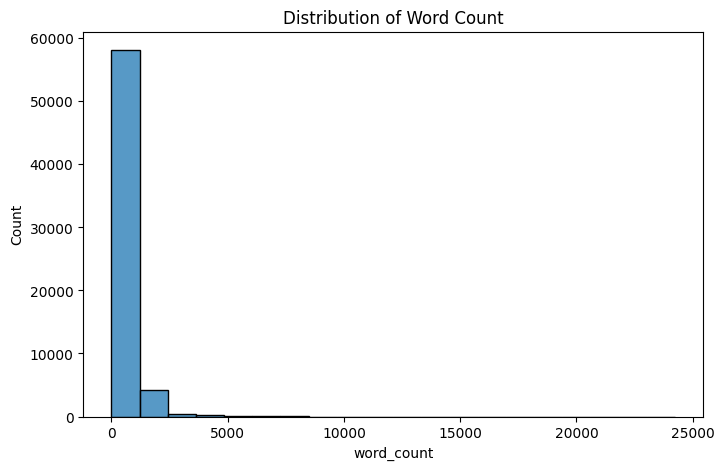

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['word_count'], bins=20)

plt.title("Distribution of Word Count")
plt.show()

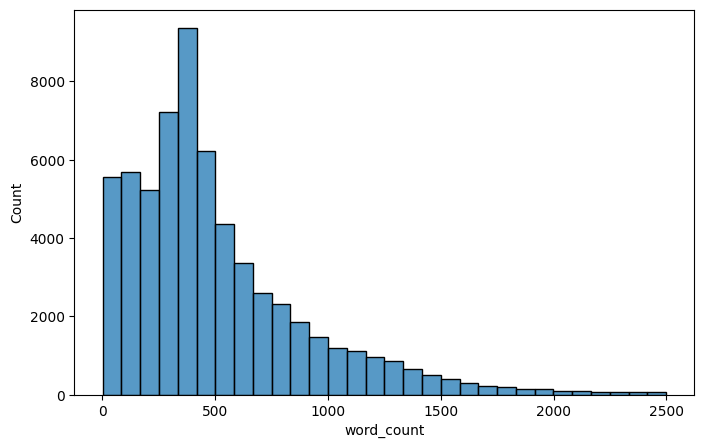

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df['word_count']<2500]['word_count'],
    bins=30
)

plt.show()

## Investigating Outliers

In [30]:
df['word_count'].quantile([0.90,0.95,0.99,0.995,0.999])

,word_count
0.900,1106.000
0.950,1404.000
0.990,2678.640
0.995,3702.910
0.999,6666.384


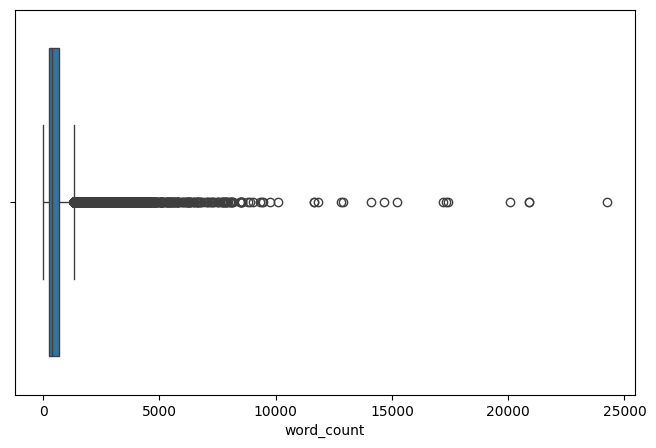

In [31]:
# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=df['word_count'])

plt.show()

## Comparing Fake and Ral outliers

In [32]:
df.groupby('label')[['word_count']].describe()

word_count                                                           
           count        mean         std  min    25%    50%    75%      max
label                                                                      
0        34790.0  578.268899  564.396108  1.0  241.0  427.0  784.0  14641.0
1        28320.0  509.020798  661.744030  1.0  241.0  379.0  564.0  24234.0

<Axes: xlabel='label', ylabel='word_count'>

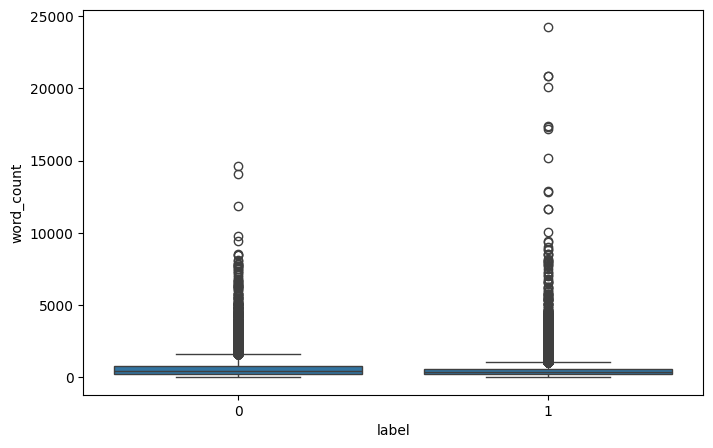

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='word_count'
)

In [34]:
df[df['label']==1].sample(5)

,title,text,label,char_count,word_count,sentence_count
41880,Cop Fired After Shooting Own 11-year-old Daugh...,Home / Badge Abuse / Cop Fired After Shooting ...,1,4443,737,34
18412,DEMOCRAT LEGAL EXPERT Shocks The Left With His...,Legal expert and Constitutional law professor ...,1,5822,980,46
55048,Fascism Over Farmers? The Troubling Priorities...,[Photo: Corporate dairy Credit: Gunnar Richter...,1,15377,2490,131
28799,TWO HIGH SCHOOL JROTC Members Tell INCREDIBLE ...,ABC News When two Marjory Stoneman Douglas Hi...,1,1835,332,15
14435,Senate Asks For Defense Secretary’s E-mails Af...,There must be something in the water in Washin...,1,1611,262,11


In [35]:
df[df['label']==0].sample(5)

,title,text,label,char_count,word_count,sentence_count
14865,Senior official in US-backed Syria forces defe...,AMMAN (Reuters) - A senior commander defected ...,0,2130,344,21
49452,Omar Mateen Posted to Facebook Amid Orlando At...,"JENSEN BEACH, Fla. — The gunman who committ...",0,7560,1291,82
13799,Microcephaly Found in Babies of Zika-Infected ...,It is the news that doctors and families in th...,0,7405,1252,61
36709,Mattis says U.S. military policy in Syria unch...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,0,659,109,6
25941,"A Big Blast in North Korea, and Big Questions ...",GENEVA — North Korea’s latest test of an at...,0,10090,1681,81


#Text Preprocessing

In [36]:
# Create a single text column for NLP processing
df['content'] = df['title'] + " " + df['text']

In [37]:
df.shape

(63110, 7)

In [38]:
df[['title', 'text', 'content']].sample(3)

,title,text,content
40767,U.S. top court again faults North Carolina on ...,WASHINGTON (Reuters) - The U.S. Supreme Court ...,U.S. top court again faults North Carolina on ...
67640,The Funniest And Most Obscene Local News FAIL...,You can always count on local newscasters to m...,The Funniest And Most Obscene Local News FAIL...
19462,Texas Teacher Calls 12-Year-Old Boy A ‘Terror...,A Texas teacher has been removed from her clas...,Texas Teacher Calls 12-Year-Old Boy A ‘Terror...


In [39]:
import re

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_emails(text):
    return re.sub(r'\S+@\S+', '', text)

def remove_html(text):
    return re.sub(r'<.*?>', '', text)

def remove_newlines(text):
    return text.replace('\n', ' ')

def remove_tabs(text):
    return text.replace('\t', ' ')

def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

def clean_text(text):
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_html(text)
    text = remove_newlines(text)
    text = remove_tabs(text)
    text = remove_extra_spaces(text)
    return text

In [40]:
df['clean_content'] = df['content'].apply(clean_text)

In [41]:
df["clean_content"].head()

,clean_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...


## Text Normalization

In [42]:
def to_lowercase(text):
    return text.lower()

df['normalized_content'] = df['clean_content'].apply(to_lowercase)

In [43]:
print("Unique words before lowercasing:")
print(df['clean_content'].str.split().explode().nunique())

Unique words before lowercasing:
790517


In [44]:
print("Unique words after lowercasing:")
print(df['normalized_content'].str.split().explode().nunique())

Unique words after lowercasing:
701371


In [45]:
import string

def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

In [46]:
df['normalized_content'] = df['normalized_content'].apply(remove_punctuation)
print("Clean Content")
print(df['clean_content'].str.split().explode().nunique())

print("\nLowercase Only")
print(df['clean_content'].str.lower().str.split().explode().nunique())

print("\nNormalized Content")
print(df['normalized_content'].str.split().explode().nunique())


Clean Content
790517

Lowercase Only
701371

Normalized Content
440621


In [47]:
original = 790517
lower = 701371
normalized = 440621

print(f"Lowercase reduction: {(original-lower)/original*100:.2f}%")
print(f"Punctuation reduction: {(lower-normalized)/lower*100:.2f}%")
print(f"Overall reduction: {(original-normalized)/original*100:.2f}%")

Lowercase reduction: 11.28%
Punctuation reduction: 37.18%
Overall reduction: 44.26%


#Tokenization


In [48]:
import nltk

nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['tokens'] = df['normalized_content'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [49]:
df[['normalized_content', 'tokens']].head()

,normalized_content,tokens
0,law enforcement on high alert following threat...,"[law, enforcement, on, high, alert, following,..."
1,did they post their votes for hillary already,"[did, they, post, their, votes, for, hillary, ..."
2,unbelievable obama’s attorney general says mos...,"[unbelievable, obama, ’, s, attorney, general,..."
3,bobby jindal raised hindu uses story of christ...,"[bobby, jindal, raised, hindu, uses, story, of..."
4,satan 2 russia unvelis an image of its terrify...,"[satan, 2, russia, unvelis, an, image, of, its..."


##Stopword Removal

In [50]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [51]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]


df['tokens'] = df['tokens'].apply(remove_stopwords)

In [52]:
df[['normalized_content', 'tokens']].head()

,normalized_content,tokens
0,law enforcement on high alert following threat...,"[law, enforcement, high, alert, following, thr..."
1,did they post their votes for hillary already,"[post, votes, hillary, already]"
2,unbelievable obama’s attorney general says mos...,"[unbelievable, obama, ’, attorney, general, sa..."
3,bobby jindal raised hindu uses story of christ...,"[bobby, jindal, raised, hindu, uses, story, ch..."
4,satan 2 russia unvelis an image of its terrify...,"[satan, 2, russia, unvelis, image, terrifying,..."


## Stemming

In [53]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [54]:
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]


df['stemmed_tokens'] = df['tokens'].apply(stem_tokens)


## Lematization with POS Tagging

In [55]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [56]:
nltk.download('wordnet')
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [57]:
def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('N'):
        return wordnet.NOUN

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN

In [58]:
def lemmatize_with_pos(tokens):

    tagged_tokens = pos_tag(tokens)

    lemmatized = []

    for word, tag in tagged_tokens:

        wn_tag = get_wordnet_pos(tag)

        lemma = lemmatizer.lemmatize(word, pos=wn_tag)

        lemmatized.append(lemma)

    return lemmatized

In [59]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63110 entries, 0 to 72132
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               63110 non-null  object
 1   text                63110 non-null  object
 2   label               63110 non-null  int64 
 3   char_count          63110 non-null  int64 
 4   word_count          63110 non-null  int64 
 5   sentence_count      63110 non-null  int64 
 6   content             63110 non-null  object
 7   clean_content       63110 non-null  object
 8   normalized_content  63110 non-null  object
 9   tokens              63110 non-null  object
 10  stemmed_tokens      63110 non-null  object
 11  lemmatized_tokens   63110 non-null  object
dtypes: int64(4), object(8)
memory usage: 8.3+ MB


#Train_Test_Split

In [61]:
X = df['lemmatized_tokens']
y = df['label']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
X_train.iloc[0]

['two',
 'u',
 'citizen',
 'arrested',
 'tunisia',
 'tie',
 'daesh',
 '0',
 '35',
 '3',
 '0',
 'two',
 'unnamed',
 'american',
 'reportedly',
 'arrested',
 'northern',
 'tunisia',
 'tuesday',
 'suspicion',
 'tie',
 'terrorist',
 'group',
 'brother',
 'aged',
 '32',
 '33',
 'born',
 'michigan',
 'arrested',
 'near',
 'algerian',
 'border',
 '©',
 'photo',
 'youtubepresstv',
 'documentary',
 'u',
 'ruling',
 'daesh',
 'involvement',
 'afghanistan',
 'offensive',
 'claimed',
 'north',
 'african',
 'country',
 'studying',
 'computer',
 'science',
 'university',
 'jendouba',
 'according',
 'tunisian',
 'interior',
 'ministry',
 'spokesman',
 'tunisialive',
 'reported',
 'neighbor',
 'area',
 'brother',
 'renting',
 'house',
 'alerted',
 'police',
 'suspicious',
 'behavior',
 'investigation',
 'revealed',
 'two',
 'men',
 'student',
 'instead',
 'recent',
 'convert',
 'islam',
 'jihadist',
 'material',
 'computer',
 'wanted',
 'tunisia',
 'placed',
 'sharia',
 'law',
 'described',
 'unwashed

#Vectoriztion

## TF-IDF

In [64]:
X_train_text = X_train.apply(lambda x: " ".join(x))

X_test_text = X_test.apply(lambda x: " ".join(x))

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [66]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

In [67]:
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [68]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(50488, 5000)
(12622, 5000)


## Word2Vec

In [69]:
!pip install -q gensim

import numpy as np
from gensim.models import Word2Vec

In [70]:
w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0,              # CBOW
    epochs=5,
    seed=42
)

In [71]:
print("Vocabulary Size:", len(w2v_model.wv))

print("\nVector for 'government':")
print(w2v_model.wv['government'])

Vocabulary Size: 130027

Vector for 'government':
[-1.4715352  -0.5592724  -3.7641163  -1.329274    1.5388992  -1.9669722
 -1.2008563  -5.057107    1.66303    -0.62799513  6.414996   -0.14715621
 -0.722069    2.437336    0.16168267  0.40834478  1.386815    2.895457
  0.32269934  0.7464191   0.6964686  -0.3032918   0.03580632 -1.8416294
 -1.0972244   0.45516637  1.2853588   1.1703161   1.1507901  -1.590149
  2.8125198   0.90824187 -2.6504645  -3.1906946  -1.2866904   1.0671824
 -0.28056818 -1.6053982   1.9115512   3.3099358   0.03595069 -1.7071649
 -1.1208616   2.5045886   0.69758725 -0.1578555  -4.031873   -0.47892633
 -1.7383857   0.79668486  1.094304    4.2813473   1.107456    0.05927195
  0.7584315   0.4222184   0.6432014  -0.2936743   1.3257943  -0.748715
 -0.7571505  -2.0638742   0.29691544 -2.6332655   0.46480343  1.8173113
 -0.55878544 -1.8926862   0.59113896 -3.2075958  -0.54440445  1.8414375
 -0.5889355   1.9540933  -1.0586948   1.8700662   0.48895773 -3.1951292
  1.7673554   

In [72]:
def average_word_vectors(tokens, model):

    vectors = []

    for word in tokens:

        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [73]:
X_train_w2v = np.array(
    X_train.apply(
        lambda tokens: average_word_vectors(tokens, w2v_model)
    ).tolist()
)

In [74]:
X_test_w2v = np.array(
    X_test.apply(
        lambda tokens: average_word_vectors(tokens, w2v_model)
    ).tolist()
)

In [75]:
print("Training Shape :", X_train_w2v.shape)
print("Testing Shape  :", X_test_w2v.shape)

Training Shape : (50488, 100)
Testing Shape  : (12622, 100)


In [76]:
w2v_model.wv.most_similar("government", topn=10)

[('authority', 0.6451655626296997),
 ('military', 0.5032927989959717),
 ('congress', 0.485129714012146),
 ('agency', 0.4826320707798004),
 ('administration', 0.4616535007953644),
 ('bureaucracy', 0.46156930923461914),
 ('decentralized', 0.4594844579696655),
 ('bank', 0.452085942029953),
 ('regime', 0.4484421908855438),
 ('effectively', 0.44822850823402405)]

#Model Training

## TF-IDF Model Training

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

X_train = X_train_tfidf
X_test = X_test_tfidf

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_score = model.predict_proba(X_train)[:, 1]
        y_test_score = model.predict_proba(X_test)[:, 1]
    else:
        y_train_score = model.decision_function(X_train)
        y_test_score = model.decision_function(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_score)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_score)

    print(f"\n{name}")

    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Training Precision : {train_precision:.4f}")
    print(f"Training Recall : {train_recall:.4f}")
    print(f"Training F1 Score : {train_f1:.4f}")
    print(f"Training ROC AUC : {train_auc:.4f}")

    print("-" * 50)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Precision : {test_precision:.4f}")
    print(f"Test Recall : {test_recall:.4f}")
    print(f"Test F1 Score : {test_f1:.4f}")
    print(f"Test ROC AUC : {test_auc:.4f}")

    print("=" * 50)


Naive Bayes
Training Accuracy : 0.8566
Training Precision : 0.8268
Training Recall : 0.8606
Training F1 Score : 0.8434
Training ROC AUC : 0.9312
--------------------------------------------------
Test Accuracy : 0.8462
Test Precision : 0.8146
Test Recall : 0.8510
Test F1 Score : 0.8324
Test ROC AUC : 0.9240

Logistic Regression
Training Accuracy : 0.9582
Training Precision : 0.9533
Training Recall : 0.9537
Training F1 Score : 0.9535
Training ROC AUC : 0.9921
--------------------------------------------------
Test Accuracy : 0.9426
Test Precision : 0.9359
Test Recall : 0.9363
Test F1 Score : 0.9361
Test ROC AUC : 0.9867

Linear SVM
Training Accuracy : 0.9776
Training Precision : 0.9747
Training Recall : 0.9754
Training F1 Score : 0.9751
Training ROC AUC : 0.9974
--------------------------------------------------
Test Accuracy : 0.9523
Test Precision : 0.9447
Test Recall : 0.9493
Test F1 Score : 0.9470
Test ROC AUC : 0.9894

Random Forest
Training Accuracy : 1.0000
Training Precision : 

###Hyperparameter Tuning(TF-IDF)

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


models = {

    "Logistic Regression": (
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["liblinear", "lbfgs"]
        }
    ),

    "Linear SVM": (
        LinearSVC(
            max_iter=5000,
            random_state=42
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "loss": ["hinge", "squared_hinge"]
        }
    )

}

for name, (model, params) in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=3,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("Best Parameters:", search.best_params_)

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_train_score = best_model.predict_proba(X_train)[:, 1]
        y_test_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_train_score = best_model.decision_function(X_train)
        y_test_score = best_model.decision_function(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_score)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_score)

    print()

    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Training Precision : {train_precision:.4f}")
    print(f"Training Recall : {train_recall:.4f}")
    print(f"Training F1 Score : {train_f1:.4f}")
    print(f"Training ROC AUC : {train_auc:.4f}")

    print("-" * 60)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Precision : {test_precision:.4f}")
    print(f"Test Recall : {test_recall:.4f}")
    print(f"Test F1 Score : {test_f1:.4f}")
    print(f"Test ROC AUC : {test_auc:.4f}")

    print("=" * 70)

Logistic Regression
Best Parameters: {'solver': 'liblinear', 'C': 10}

Training Accuracy : 0.9777
Training Precision : 0.9748
Training Recall : 0.9755
Training F1 Score : 0.9751
Training ROC AUC : 0.9973
------------------------------------------------------------
Test Accuracy : 0.9505
Test Precision : 0.9429
Test Recall : 0.9470
Test F1 Score : 0.9449
Test ROC AUC : 0.9895
Linear SVM
Best Parameters: {'loss': 'squared_hinge', 'C': 1}

Training Accuracy : 0.9776
Training Precision : 0.9747
Training Recall : 0.9754
Training F1 Score : 0.9751
Training ROC AUC : 0.9974
------------------------------------------------------------
Test Accuracy : 0.9523
Test Precision : 0.9447
Test Recall : 0.9493
Test F1 Score : 0.9470
Test ROC AUC : 0.9894


##Word2Vec Model Training

In [84]:
from sklearn.naive_bayes import GaussianNB

X_train = X_train_w2v
X_test = X_test_w2v

models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_score = model.predict_proba(X_train)[:, 1]
        y_test_score = model.predict_proba(X_test)[:, 1]
    else:
        y_train_score = model.decision_function(X_train)
        y_test_score = model.decision_function(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_score)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_score)

    print(f"\n{name}")

    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Training Precision : {train_precision:.4f}")
    print(f"Training Recall : {train_recall:.4f}")
    print(f"Training F1 Score : {train_f1:.4f}")
    print(f"Training ROC AUC : {train_auc:.4f}")

    print("-" * 60)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Precision : {test_precision:.4f}")
    print(f"Test Recall : {test_recall:.4f}")
    print(f"Test F1 Score : {test_f1:.4f}")
    print(f"Test ROC AUC : {test_auc:.4f}")

    print("=" * 70)


Gaussian Naive Bayes
Training Accuracy : 0.8042
Training Precision : 0.7531
Training Recall : 0.8387
Training F1 Score : 0.7936
Training ROC AUC : 0.8944
------------------------------------------------------------
Test Accuracy : 0.7955
Test Precision : 0.7421
Test Recall : 0.8342
Test F1 Score : 0.7855
Test ROC AUC : 0.8870

Logistic Regression
Training Accuracy : 0.9204
Training Precision : 0.9151
Training Recall : 0.9067
Training F1 Score : 0.9109
Training ROC AUC : 0.9739
------------------------------------------------------------
Test Accuracy : 0.9193
Test Precision : 0.9154
Test Recall : 0.9038
Test F1 Score : 0.9096
Test ROC AUC : 0.9723

Linear SVM
Training Accuracy : 0.9207
Training Precision : 0.9154
Training Recall : 0.9072
Training F1 Score : 0.9113
Training ROC AUC : 0.9740
------------------------------------------------------------
Test Accuracy : 0.9179
Test Precision : 0.9141
Test Recall : 0.9018
Test F1 Score : 0.9079
Test ROC AUC : 0.9725

Random Forest
Training 

###Hyperparameter Tuning(Word2Vec)

In [85]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


models = {

    "Logistic Regression": (
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["liblinear", "lbfgs"]
        }
    ),

    "Linear SVM": (
        LinearSVC(
            max_iter=5000,
            random_state=42
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "loss": ["hinge", "squared_hinge"]
        }
    )

}

for name, (model, params) in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=3,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("Best Parameters:", search.best_params_)

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_train_score = best_model.predict_proba(X_train)[:, 1]
        y_test_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_train_score = best_model.decision_function(X_train)
        y_test_score = best_model.decision_function(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_score)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_score)

    print()

    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Training Precision : {train_precision:.4f}")
    print(f"Training Recall : {train_recall:.4f}")
    print(f"Training F1 Score : {train_f1:.4f}")
    print(f"Training ROC AUC : {train_auc:.4f}")

    print("-" * 60)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Precision : {test_precision:.4f}")
    print(f"Test Recall : {test_recall:.4f}")
    print(f"Test F1 Score : {test_f1:.4f}")
    print(f"Test ROC AUC : {test_auc:.4f}")

    print("=" * 70)

Logistic Regression
Best Parameters: {'solver': 'liblinear', 'C': 100}

Training Accuracy : 0.9207
Training Precision : 0.9152
Training Recall : 0.9074
Training F1 Score : 0.9113
Training ROC AUC : 0.9741
------------------------------------------------------------
Test Accuracy : 0.9185
Test Precision : 0.9151
Test Recall : 0.9020
Test F1 Score : 0.9085
Test ROC AUC : 0.9725
Linear SVM
Best Parameters: {'loss': 'hinge', 'C': 10}

Training Accuracy : 0.9215
Training Precision : 0.9161
Training Recall : 0.9082
Training F1 Score : 0.9121
Training ROC AUC : 0.9739
------------------------------------------------------------
Test Accuracy : 0.9197
Test Precision : 0.9156
Test Recall : 0.9045
Test F1 Score : 0.9100
Test ROC AUC : 0.9724


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#Conclusion

--> Successfully preprocessed the WELFake dataset through text cleaning, tokenization, stopword removal, and lemmatization to prepare high-quality input for machine learning models.

--> Implemented and compared two feature extraction techniques (TF-IDF and Word2Vec) with four classifiers (Naive Bayes, Logistic Regression, Linear SVM, and Random Forest) using Accuracy, Precision, Recall, F1-score, and ROC-AUC as evaluation metrics.

--> Experimental results demonstrated that TF-IDF consistently outperformed Word2Vec, indicating that term-frequency-based representations were more effective than averaged word embeddings for fake news classification on this dataset.

--> Among all evaluated models, TF-IDF with Linear SVM achieved the best performance, with a Test Accuracy of 95.23%, F1-score of 94.70%, and ROC-AUC of 98.94%, making it the most reliable classifier.